## DATA PREPROCESSING FOR MODELING

## I. Tổng quan về dữ liệu thô

### 1. Tải thư viện & đọc file

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
import os
from sklearn.preprocessing import StandardScaler

In [2]:
path = "../data/amazon_crawl/amazon_products_US_20260324_231228.csv"
try:
    df = pd.read_csv(path)
    print("Tải dữ liệu thành công")
except Exception as e:
    print(f"Tải dữ liệu thất bại: {e}")

Tải dữ liệu thành công


### 2. Thông tin cơ bản

In [3]:
df.head()

,asin,title,price,original_price,rating,reviews,currency,is_best_seller,is_amazon_choice,is_prime,...,video_thumbnail,has_video,key_features,full_description,technical_details,product_details,has_aplus_content,aplus_images,has_brand_story,frequently_bought_together
0,B08NHSPCR6,HP Chromebook 11A G8 Education Edition AMD A4-...,NaN,NaN,4.1,1161,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B0GR6F8HXV,Apple 2026 MacBook Neo 13-inch Laptop with A18...,749.00,NaN,4.8,73,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B0D7NVS6RV,"Lenovo Yoga 7i 2-in-1 Laptop, 16&quot; 2K Touc...",799.99,NaN,4.5,167,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B08H5878D3,LEXiBOOK Spider-Man - Educational and Bilingua...,49.99,NaN,4.2,1355,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,B0791H74NT,Creative Pebble 2.0 USB-Powered Desktop Speake...,23.74,24.99,4.5,67192,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,asin,title,price,original_price,rating,reviews,currency,is_best_seller,is_amazon_choice,is_prime,...,video_thumbnail,has_video,key_features,full_description,technical_details,product_details,has_aplus_content,aplus_images,has_brand_story,frequently_bought_together
9175,B086P8YGYW,L&#x27;ANGE HAIR Le Vite Straightening Brush |...,39.00,NaN,4.3,9652,USD,True,True,False,...,https://m.media-amazon.com/images/I/51ZBnaDgA8...,True,[],NaN,{'Product Benefits': 'Adjustable temperature r...,{'Product Dimensions': '13.74 x 2.24 x 4.41 in...,True,['https://m.media-amazon.com/images/S/aplus-me...,True,"[{'name': ""This item: L'ANGE HAIR Le Vite Str..."
9176,B09MYSWLGT,"SUNHZMCKP Magnetic Screwdriver Set 66-Piece, S...",39.99,NaN,4.7,2759,USD,True,True,False,...,https://m.media-amazon.com/images/I/81vbZh2aDd...,True,['【TOP MATERIALS】: Professional screwdriver ki...,NaN,"{'Brand Name': 'SUNHZ MCKP', 'Manufacturer': '...","{'Brand': 'SUNHZ MCKP', 'Color': 'Blue, Yellow...",True,['https://m.media-amazon.com/images/S/aplus-me...,True,[]
9177,B087G6TGJL,Fathers Day Dad Gifts from Daughter Son Wife S...,9.49,9.99,4.5,21528,USD,True,False,False,...,https://m.media-amazon.com/images/I/51S61p7TfC...,True,['The One Tool Can Replace The Whole Set: Focu...,NaN,"{'Head Style': 'Flat', 'Operation Mode': 'Pneu...","{'Color': 'Silver', 'Brand': 'HANPURE', 'Mater...",True,['https://m.media-amazon.com/images/S/aplus-me...,True,[{'name': 'This item: Fathers Day Dad Gifts f...
9178,B08HQ59Q91,"HYCHIKA Detail Sander, 14,000 OPM Compact Elec...",22.96,25.51,4.4,1951,USD,True,True,False,...,https://m.media-amazon.com/images/I/51mRT3QvrQ...,True,['🍀[Quiet and Efficient] - HYCHIKA detail sand...,NaN,"{'Voltage': '120 Volts (AC)', 'Power Source': ...",{'Brand': 'HYCHIKA BETTER TOOLS FOR BETTER LIF...,True,['https://m.media-amazon.com/images/S/aplus-me...,True,"[{'name': 'This item: HYCHIKA Detail Sander, ..."
9179,B07WDJ8Q79,44pcs Cutting Wheel Set Compatible with Plasti...,9.99,NaN,4.4,13545,USD,True,False,False,...,NaN,False,['RESIN CUT OFF DISCS – With low heat generati...,NaN,"{'Material Type': 'Plastic,Resin', 'Grit Mater...","{'Grit Material': 'Diamond', 'Product Dimensio...",True,['https://m.media-amazon.com/images/S/aplus-me...,True,[{'name': 'This item: 44pcs Cutting Wheel Set...


#### 2.1. Kích thước dữ liệu

In [5]:
print(f"Data shape: {df.shape}")

num_rows, num_columns = df.shape
print(f"Số dòng: {num_rows}")
print(f"Số cột: {num_columns}")

Data shape: (9180, 58)
Số dòng: 9180
Số cột: 58


#### 2.2. Kiểu dữ liệu của các đặc trưng

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9180 entries, 0 to 9179
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   asin                        9180 non-null   object 
 1   title                       9180 non-null   object 
 2   price                       8910 non-null   float64
 3   original_price              4096 non-null   float64
 4   rating                      9157 non-null   float64
 5   reviews                     9180 non-null   int64  
 6   currency                    8939 non-null   object 
 7   is_best_seller              9180 non-null   bool   
 8   is_amazon_choice            9180 non-null   bool   
 9   is_prime                    9180 non-null   bool   
 10  sales_volume                8308 non-null   object 
 11  main_category               9180 non-null   object 
 12  category_hierarchy          9180 non-null   object 
 13  crawl_category              9180 

#### 2.3. Ý nghĩa của các đặc trưng

| STT | Feature | Đơn vị | Ý nghĩa |
|-----|--------|-------|--------|
| 1 | asin | Không có | Mã định danh duy nhất của sản phẩm trên Amazon (ASIN). |
| 2 | title | Không có | Tiêu đề sản phẩm hiển thị trên Amazon, chứa thông tin mô tả chính. |
| 3 | price | USD ($) | Giá hiện tại của sản phẩm tại thời điểm crawl. |
| 4 | original_price | USD ($) | Giá gốc trước khi giảm giá (nếu có). |
| 5 | rating | Điểm (0–5) | Điểm đánh giá trung bình từ người dùng. |
| 6 | reviews | Số lượng | Tổng số lượt đánh giá (reviews) của sản phẩm. |
| 7 | currency | Không có | Đơn vị tiền tệ (ví dụ: USD). |
| 8 | is_best_seller | Boolean | Sản phẩm có thuộc danh sách Best Seller hay không. |
| 9 | is_amazon_choice | Boolean | Sản phẩm có được gắn nhãn “Amazon’s Choice” hay không. |
| 10 | is_prime | Boolean | Sản phẩm có hỗ trợ Amazon Prime hay không. |
| 11 | sales_volume | Không có | Số lượng bán ra (thường dạng text như “500+ bought”). |
| 12 | main_category | Không có | Danh mục chính của sản phẩm (ví dụ: electronics). |
| 13 | category_hierarchy | Không có | Cấu trúc phân cấp danh mục (dạng list hoặc JSON). |
| 14 | crawl_category | Không có | Danh mục dùng khi crawl dữ liệu. |
| 15 | link | URL | Đường dẫn đến trang sản phẩm. |
| 16 | image_url | URL | Đường dẫn đến ảnh chính của sản phẩm. |
| 17 | delivery_info | Không có | Thông tin giao hàng (thời gian, phí, khu vực). |
| 18 | number_of_offers | Số lượng | Số người bán cung cấp sản phẩm. |
| 19 | lowest_offer_price | USD ($) | Giá thấp nhất trong các offer. |
| 20 | has_variations | Boolean | Sản phẩm có nhiều biến thể hay không. |
| 21 | is_climate_friendly | Boolean | Sản phẩm có thân thiện môi trường hay không. |
| 22 | variation_dimensions | Không có | Các chiều biến thể (màu, size, cấu hình...). |
| 23 | variants | Không có | Thông tin các biến thể hiện tại. |
| 24 | all_variants | Không có | Danh sách toàn bộ biến thể của sản phẩm. |
| 25 | top_reviews | Không có | Các đánh giá nổi bật của sản phẩm. |
| 26 | detailed_rating | Không có | Phân bố rating chi tiết (5 sao, 4 sao...). |
| 27 | current_price | USD ($) | Giá hiện tại (có thể trùng với price). |
| 28 | product_name | Không có | Tên rút gọn của sản phẩm. |
| 29 | slug | Không có | Chuỗi định danh URL thân thiện (SEO). |
| 30 | parent_asin | Không có | ASIN của sản phẩm cha (nếu là biến thể). |
| 31 | landing_asin | Không có | ASIN trang landing chính. |
| 32 | brand_info | Không có | Thông tin thương hiệu. |
| 33 | brand_url | URL | Đường dẫn tới trang thương hiệu. |
| 34 | brand_urls | URL | Danh sách các URL liên quan đến brand. |
| 35 | unit_price | USD ($) | Giá trên mỗi đơn vị sản phẩm. |
| 36 | unit_count | Số lượng | Số lượng đơn vị trong sản phẩm. |
| 37 | min_order_quantity | Số lượng | Số lượng tối thiểu cần mua (hiện tại null). |
| 38 | country | Không có | Quốc gia bán hoặc phân phối sản phẩm. |
| 39 | availability | Không có | Tình trạng còn hàng. |
| 40 | condition | Không có | Tình trạng sản phẩm (new, used...). |
| 41 | estimated_delivery_date | Ngày | Ngày giao hàng dự kiến. |
| 42 | customer_feedback_summary | Không có | Tổng hợp phản hồi khách hàng (hiện null). |
| 43 | top_reviews_global | Không có | Review nổi bật toàn cầu. |
| 44 | is_bestseller | Không có | Cờ bestseller (phiên bản khác của is_best_seller). |
| 45 | main_image_url | URL | URL ảnh chính chi tiết. |
| 46 | additional_image_urls | URL | Danh sách ảnh bổ sung. |
| 47 | product_videos | Không có | Video chính thức của sản phẩm. |
| 48 | user_videos | Không có | Video do người dùng đăng. |
| 49 | video_thumbnail | URL | Ảnh thumbnail của video. |
| 50 | has_video | Boolean | Sản phẩm có video hay không. |
| 51 | key_features | Không có | Các đặc điểm nổi bật (bullet points). |
| 52 | full_description | Không có | Mô tả chi tiết sản phẩm. |
| 53 | technical_details | Không có | Thông số kỹ thuật chi tiết. |
| 54 | product_details | Không có | Thông tin chi tiết bổ sung. |
| 55 | has_aplus_content | Boolean | Có nội dung A+ (Enhanced Brand Content). |
| 56 | aplus_images | URL | Hình ảnh trong nội dung A+. |
| 57 | has_brand_story | Boolean | Có câu chuyện thương hiệu hay không. |
| 58 | frequently_bought_together | Không có | Danh sách sản phẩm thường mua cùng. |

## II. Tiền xử lý dữ liệu

### 1. Lựa chọn đặc trưng

Để xây dựng một mô hình học máy hiệu quả, chúng ta cần loại bỏ các đặc trưng không mang giá trị dự báo hoặc có cấu trúc không phù hợp. Việc này giúp giảm chiều dữ liệu, tránh hiện tượng Overfitting và tối ưu hóa thời gian huấn luyện.

**Nhóm 1: Metadata, URL & Identifiers**
- **Đặc trưng:** `link`, `image_url`, `main_image_url`, `additional_image_urls`, `aplus_images`, `brand_url`, `brand_urls`, `video_thumbnail`, `product_videos`, `user_videos`, `slug`, `title`, `currency`.
- **Lý do:** Các cột này chứa đường dẫn (URL) phục vụ hiển thị trên giao diện web hoặc định danh SEO. Chúng không thể dùng để thực hiện các phép toán thống kê (tính trung bình, tổng) hay biểu diễn trực quan trên các biểu đồ thông thường.

**Lưu ý về `asin`:** Chúng ta sẽ tạm thời giữ lại cột `asin` để thực hiện việc kiểm tra và xóa các bản ghi trùng lặp ở bước tiếp theo. Sau khi hoàn tất xử lý trùng lặp, đặc trưng này sẽ được loại bỏ hoàn toàn khỏi tập dữ liệu huấn luyện.

**Nhóm 2: Dữ liệu dư thừa**
- **Đặc trưng:** `current_price`, `is_bestseller`, `parent_asin`, `landing_asin`, `main_category`.
- **Lý do:** Loại bỏ sự trùng lặp thông tin (ví dụ: `current_price` giống `price`) để tránh hiện tượng đa cộng tuyến và làm nhẹ bộ dữ liệu.

**Nhóm 3: Dữ liệu cấu trúc phức tạp (JSON/List/Long Text)**
- **Đặc trưng:** `category_hierarchy`, `variation_dimensions`, `variants`, `all_variants`, `frequently_bought_together`, `top_reviews`, `top_reviews_global`, `detailed_rating`, `technical_details`, `product_details`, `key_features`, `full_description`.
- **Lý do:** Đây là dữ liệu phi cấu trúc, đòi hỏi các kỹ thuật parsing hoặc NLP phức tạp, không phù hợp cho các mô hình dự báo dựa trên đặc trưng số/phân loại.

In [7]:
unnecessary_features = [
    'link', 'image_url', 'main_image_url', 'additional_image_urls', 'aplus_images', 
    'brand_url', 'brand_urls', 'video_thumbnail', 'product_videos', 'user_videos', 'slug',
    'title', 'currency',
    
    'current_price', 'is_bestseller', 'parent_asin', 'landing_asin', 'main_category',
    
    'category_hierarchy', 'variation_dimensions', 'variants', 'all_variants', 
    'frequently_bought_together', 'top_reviews', 'top_reviews_global', 'detailed_rating',
    'technical_details', 'product_details', 'key_features', 'full_description'
]

df = df.drop(columns=unnecessary_features, errors="ignore")

print(f"Số lượng đặc trưng đã bị loại bỏ: {len(unnecessary_features)}")
print(f"Kích thước dữ liệu còn lại: {df.shape}")

Số lượng đặc trưng đã bị loại bỏ: 30
Kích thước dữ liệu còn lại: (9180, 28)


### 2. Kiểm tra tính nhất quán dữ liệu

Trước khi thực hiện các bước làm sạch sâu hơn, chúng ta cần đảm bảo dữ liệu tuân thủ các quy tắc logic và định dạng chuẩn. Bước này giúp phát hiện các giá trị "rác" ẩn dưới dạng văn bản hoặc các con số phi lý.

**Các nội dung kiểm tra:**
- **Định dạng kiểu dữ liệu:** Đảm bảo các cột số (`price`, `rating`, `reviews`) thực sự ở dạng Numerical thay vì Object (chuỗi).
- **Giá trị giả (Placeholders):** Thay thế các chuỗi văn bản trống hoặc mang ý nghĩa "trống" như `[]`, `{}`, `missing value`, `N/A` bằng giá trị NaN thực thụ để máy tính có thể xử lý.
- **Logic nghiệp vụ (Business Logic):**
  - Giá sản phẩm (`price`) và lượt đánh giá (`reviews`) không được âm.
  - Điểm đánh giá (`rating`) phải nằm trong khoảng từ 1 đến 5.
  - Đảm bảo các biến Boolean chỉ chứa hai giá trị `True`/`False`.

In [8]:
# Chuyển đổi các giá trị Placeholder về NaN thực sự
placeholders = ["[]", "{}", "", "missing value", "N/A", "nan"]
df = df.replace(to_replace=placeholders, value=np.nan)

In [9]:
# Ép kiểu dữ liệu (đề phòng dữ liệu số bị dính text)
numeric_cols = ['price', 'original_price', 'rating', 'reviews', 'number_of_offers', 'lowest_offer_price']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [10]:
# Kiểm tra logic phi lý
inconsistent_price = df[df["price"] < 0].shape[0]
inconsistent_reviews = df[df["reviews"] < 0].shape[0]
inconsistent_rating = df[(df["rating"] < 1) | (df["rating"] > 5)].dropna(subset=["rating"]).shape[0]

print(f"Số lượng dòng có price phi lý (<0): {inconsistent_price}")
print(f"Số lượng dòng có reviews phi lý (<0): {inconsistent_price}")
print(f"Số lượng dòng có rating sai range (1-5): {inconsistent_rating}")

# Xử lý: Đưa các giá trị phi lý về NaN để xử lý ở bước Missing Values
df.loc[df["price"] < 0, "price"] = np.nan
df.loc[df["reviews"] < 0, "reviews"] = np.nan
df.loc[(df["rating"] < 1) | (df["rating"] > 5), "rating"] = np.nan

Số lượng dòng có price phi lý (<0): 0
Số lượng dòng có reviews phi lý (<0): 0
Số lượng dòng có rating sai range (1-5): 0


In [11]:
# Kiểm tra tính nhất quán của các đặc trưng Boolean
print("--- Kiểm tra các giá trị duy nhất trong cột Boolean ---")
bool_cols = df.select_dtypes(include=['bool', 'boolean']).columns.tolist()
for col in bool_cols:
    inconsistent_bool = df[~df[col].isin([True, False, np.nan])].shape[0]

    print(f"Số lượng dòng có {col} phi lý (ngoài True/False): {inconsistent_bool}")
    
    if inconsistent_bool > 0:
        df.loc[~df[col].isin([True, False, np.nan]), col] = np.nan


--- Kiểm tra các giá trị duy nhất trong cột Boolean ---
Số lượng dòng có is_best_seller phi lý (ngoài True/False): 0
Số lượng dòng có is_amazon_choice phi lý (ngoài True/False): 0
Số lượng dòng có is_prime phi lý (ngoài True/False): 0
Số lượng dòng có has_variations phi lý (ngoài True/False): 0
Số lượng dòng có is_climate_friendly phi lý (ngoài True/False): 0


### 3. Xử lý trùng lặp

Trong quá trình thu thập dữ liệu, một sản phẩm có thể bị ghi lại nhiều lần do xuất hiện ở nhiều danh mục khác nhau hoặc do lỗi kỹ thuật. Việc tồn tại các bản ghi trùng lặp sẽ làm sai lệch hoàn toàn các kết quả thống kê và khiến mô hình bị học lặp (bias).

**Các bước thực hiện:**
- **Kiểm tra trùng lặp theo mã ASIN:** Sử dụng mã định danh duy nhất của Amazon (ASIN) để xác định các bản ghi lặp lại của cùng một mặt hàng.
- **Loại bỏ dữ liệu thừa:** Tiến hành xóa bỏ các dòng trùng lặp, chỉ giữ lại bản ghi đầu tiên xuất hiện để đảm bảo mỗi sản phẩm là duy nhất.
- **Dọn dẹp định danh:** Sau khi đã hoàn tất việc lọc trùng lặp, chúng ta tiến hành loại bỏ cột `asin` vì đây là mã định danh riêng biệt, không mang giá trị quy luật cho việc huấn luyện mô hình.

In [12]:
# Kiểm tra số lượng sản phẩm bị trùng mã ASIN
asin_duplicates = df.duplicated(subset=["asin"]).sum()
print(f"Số lượng sản phẩm bị trùng mã ASIN: {asin_duplicates}")

Số lượng sản phẩm bị trùng mã ASIN: 732


In [13]:
# Loại bỏ trùng lặp, giữ lại bản ghi đầu tiên. Chúng ta dựa trên 'asin' để đảm bảo mỗi sản phẩm là duy nhất
df = df.drop_duplicates(subset=["asin"], keep="first")

In [14]:
# Loại bỏ đặc trưng asin
df = df.drop(columns=["asin"], errors="ignore")
print(f"Kích thước dữ liệu sau khi xử lý trùng lặp và loại bỏ asin: {df.shape}")

Kích thước dữ liệu sau khi xử lý trùng lặp và loại bỏ asin: (8448, 27)


### 4. Xử lý dữ liệu khuyết thuyết

Chúng ta sẽ nhận diện các giá trị trống (kể cả các chuỗi trống `[]`, `{}`) và loại bỏ những đặc trưng không có đủ thông tin để phân tích.

#### 4.1. Thống kê và Trực quan hóa tỷ lệ khuyết thiếu

In [15]:
list_missing_values = []
samples = df.shape[0]

for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percentage = (missing_count / samples) * 100

    list_missing_values.append({
        "Feature": col,
        "Missing": missing_count,
        "Percentage": f"{missing_percentage:.2f}%"
    })

df_missing_values = pd.DataFrame(list_missing_values)
df_missing_values = df_missing_values.sort_values(by="Missing", ascending=False)
df_missing_values

,Feature,Missing,Percentage
18,min_order_quantity,8448,100.00%
23,customer_feedback_summary,8448,100.00%
17,unit_count,8216,97.25%
16,unit_price,8216,97.25%
21,condition,8193,96.98%
22,estimated_delivery_date,7602,89.99%
20,availability,7565,89.55%
15,brand_info,7413,87.75%
25,has_aplus_content,7407,87.68%
24,has_video,7407,87.68%


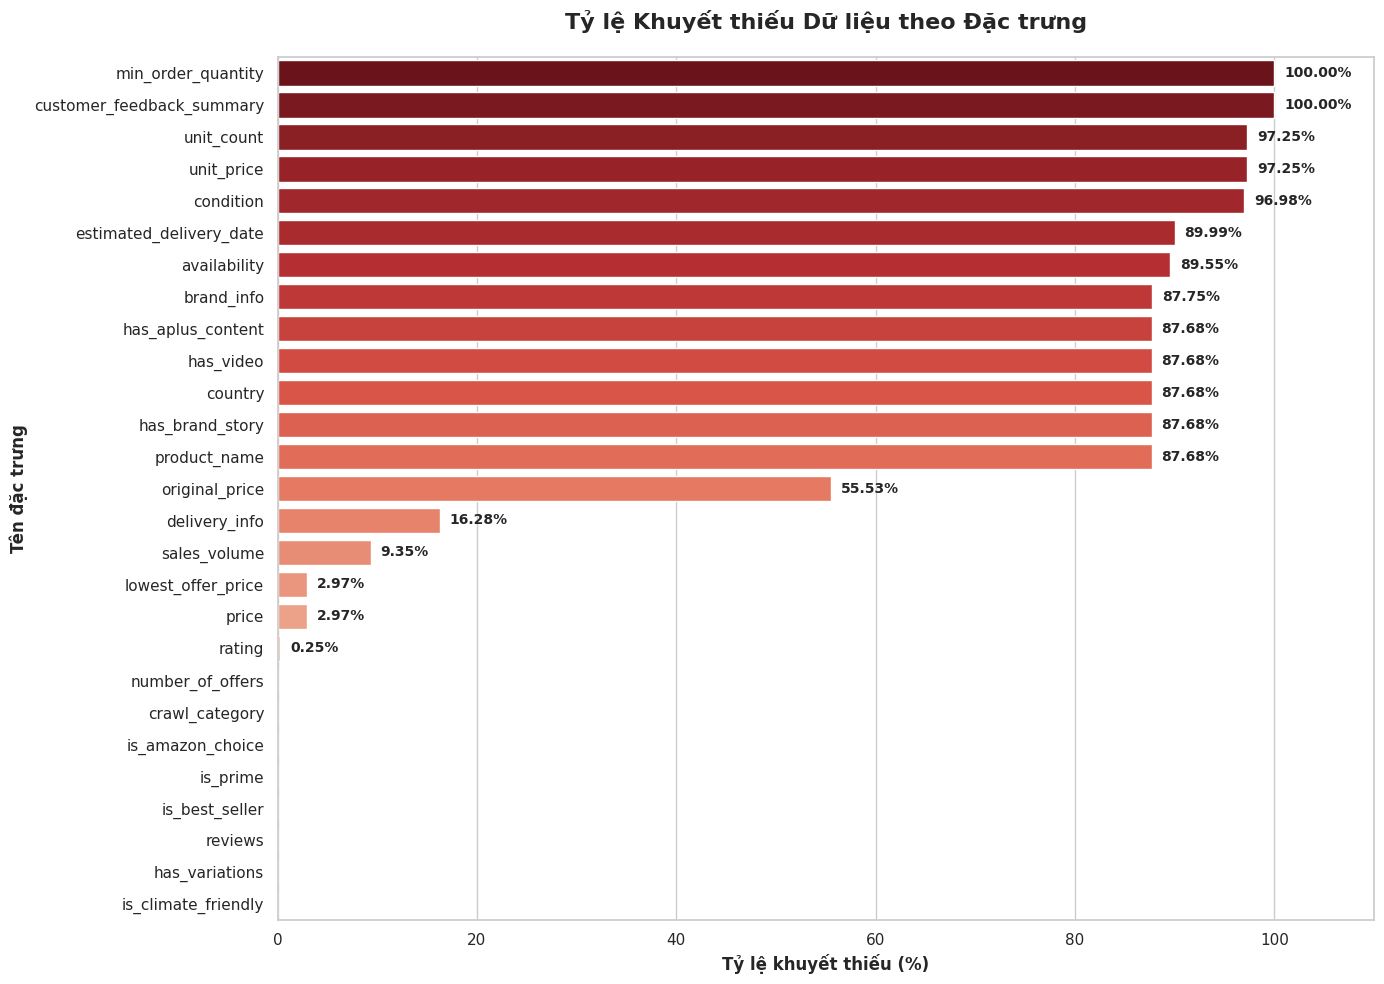

In [16]:
plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid")

if df_missing_values["Percentage"].dtype == object:
    df_missing_values["Percentage"] = df_missing_values["Percentage"].str.replace("%", "").astype(float)

df_missing_values = df_missing_values.sort_values(by="Percentage", ascending=False)

ax = sns.barplot(
    x="Percentage",
    y="Feature",
    data=df_missing_values,
    palette="Reds_r",
    hue="Feature",
    legend=False
)

plt.title("Tỷ lệ Khuyết thiếu Dữ liệu theo Đặc trưng", 
          fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Tỷ lệ khuyết thiếu (%)", fontsize=12, fontweight="bold")
plt.ylabel("Tên đặc trưng", fontsize=12, fontweight="bold")

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 1, p.get_y() + p.get_height()/2,
                f"{width:.2f}%", 
                va="center", fontsize=10, fontweight="bold")

plt.xlim(0, 110)
plt.tight_layout()
plt.show()

#### 4.2. Xử lý các đặc trưng khuyết thiếu

**Nhận xét về tình trạng khuyết thiếu dữ liệu:**

Dựa trên bảng thống kê và biểu đồ tỷ lệ khuyết thiếu, chúng ta có thể phân loại tình trạng của tập dữ liệu thành 3 nhóm chính để đưa ra chiến lược xử lý phù hợp:

**Nhóm 1: Nhóm đặc trưng khuyết thiếu nghiêm trọng (85% - 100%)**
- **Tình trạng:** Có tới 13 đặc trưng nằm trong nhóm này. Trong đó, `customer_feedback_summary` và `min_order_quantity` hoàn toàn trống (100%). Các cột khác như `unit_count`, `unit_price`, `condition`, `availability`... cũng có tỷ lệ thiếu hụt trên 90%.
- **Đánh giá:** Lượng dữ liệu thực tế còn lại quá ít (dưới 15%), không đủ để mô hình học máy tìm ra bất kỳ quy luật nào có ý nghĩa.

**Nhóm 2: Nhóm đặc trưng khuyết thiếu trung bình (10% - 56%)**
- **Tình trạng:** `original_price` (55.53%) và `delivery_info` (16.28%).
- **Đánh giá:** Mặc dù tỷ lệ thiếu của `original_price` khá cao, nhưng đây là thông tin quan trọng để tính toán mức độ giảm giá. Chúng ta cần có chiến lược điền giá trị dựa trên logic nghiệp vụ thay vì xóa bỏ.

**Nhóm 3: Nhóm đặc trưng chất lượng tốt (Dưới 10%)**
- **Tình trạng:** Các cột cốt lõi như `price`, `rating`, `reviews`, `sales_volume` và các biến phân loại (`crawl_category`, `is_amazon_choice`...) có tỷ lệ khuyết thiếu rất thấp hoặc bằng 0.
- **Đánh giá:** Đây là nhóm đặc trưng "xương sống", cung cấp nền tảng tin cậy cho việc huấn luyện mô hình.

**Đề xuất xử lý:**

Để đảm bảo mô hình phân tích không bị nhiễu và tập trung vào những thông tin có giá trị thực tế, ta đề xuất xử lý như sau:
- **Loại bỏ toàn bộ các cột có tỷ lệ khuyết thiếu >= 85%:** 
  - **Hành động:** Tiến hành xóa bỏ 13 cột thuộc Nhóm 1.
  - **Lý do:** Việc giữ lại các cột này chỉ làm tăng độ nhiễu và lãng phí tài nguyên tính toán. Việc cố gắng điền giá trị cho hơn 85% dữ liệu trống sẽ tạo ra những giá trị ảo, làm sai lệch hoàn toàn bản chất thực tế của tập dữ liệu.
- **Giữ lại các cột có tỷ lệ thiếu dưới 85%:**
  - **Hành động:** Tiếp tục duy trì các đặc trưng còn lại.
  - **Chiến lược tiếp theo:** Áp dụng logic điền giá trị phù hợp (ví dụ: `original_price` sẽ được điền bằng `price` nếu khuyết thiếu) để tối đa hóa lượng thông tin đưa vào mô hình.

In [17]:
threshold = 85.0

cols_to_drop = df_missing_values[df_missing_values["Percentage"] >= threshold]["Feature"].tolist()

print(f"Số lượng đặc trưng bị loại bỏ (>= {threshold}%): {len(cols_to_drop)}")
print(f"Danh sách các đặc trưng: {cols_to_drop}")

Số lượng đặc trưng bị loại bỏ (>= 85.0%): 13
Danh sách các đặc trưng: ['min_order_quantity', 'customer_feedback_summary', 'unit_count', 'unit_price', 'condition', 'estimated_delivery_date', 'availability', 'brand_info', 'has_aplus_content', 'has_video', 'country', 'has_brand_story', 'product_name']


In [18]:
df = df.drop(columns=cols_to_drop, errors="ignore")

print(f"Kích thước dữ liệu còn lại: {df.shape}")
print(f"Các đặc trưng còn lại: {df.columns.tolist()}")

Kích thước dữ liệu còn lại: (8448, 14)
Các đặc trưng còn lại: ['price', 'original_price', 'rating', 'reviews', 'is_best_seller', 'is_amazon_choice', 'is_prime', 'sales_volume', 'crawl_category', 'delivery_info', 'number_of_offers', 'lowest_offer_price', 'has_variations', 'is_climate_friendly']


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8448 entries, 0 to 9179
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                8197 non-null   float64
 1   original_price       3757 non-null   float64
 2   rating               8427 non-null   float64
 3   reviews              8448 non-null   float64
 4   is_best_seller       8448 non-null   bool   
 5   is_amazon_choice     8448 non-null   bool   
 6   is_prime             8448 non-null   bool   
 7   sales_volume         7658 non-null   object 
 8   crawl_category       8448 non-null   object 
 9   delivery_info        7073 non-null   object 
 10  number_of_offers     8448 non-null   int64  
 11  lowest_offer_price   8197 non-null   float64
 12  has_variations       8448 non-null   bool   
 13  is_climate_friendly  8448 non-null   bool   
dtypes: bool(5), float64(5), int64(1), object(3)
memory usage: 701.2+ KB


#### 4.3. Xử lý chi tiết các giá trị khuyết thiếu còn lại

Sau khi loại bỏ các đặc trưng quá thưa thớt, chúng ta tiến hành điền giá trị hoặc loại bỏ dòng cho các đặc trưng còn lại. Mục tiêu là tạo ra một bộ dữ liệu đầy đủ, không còn giá trị `NaN`, giúp các thuật toán học máy có thể xử lý được toàn bộ các bản ghi.

**Chiến lược xử lý cho từng đặc trưng:**
- `original_price`: Khoảng 55% sản phẩm thiếu thông tin này. Về mặt nghiệp vụ, điều này có nghĩa là sản phẩm không được giảm giá. Do đó, chúng ta điền `original_price` bằng giá hiện tại (`price`). Điều này giúp duy trì tính nhất quán khi mô hình học về mối quan hệ giữa giá thực tế và giá niêm yết.
- `sales_volume`: Điền giá trị mặc định "0 bought in past month". Việc này đảm bảo khi thực hiện Feature Engineering, các sản phẩm chưa có lượt bán sẽ được định danh chính xác là giá trị 0.
- `delivery_info`: Điền bằng chuỗi mặc định "No delivery information" để xử lý các giá trị khuyết thiếu ở dạng văn bản.
- `price` & `rating`: Đây là các biến số quan trọng nhất (thường là biến mục tiêu hoặc biến tác động mạnh). Vì tỷ lệ thiếu cực thấp (<3%), chúng ta chọn phương pháp loại bỏ các dòng. Điều này giúp loại bỏ hoàn toàn nhiễu và đảm bảo mô hình được huấn luyện trên những dữ liệu thực tế và chính xác nhất.

In [20]:
# 1. Điền giá gốc bằng giá hiện tại
df["original_price"] = df["original_price"].fillna(df["price"])

# 2. Điền giá trị mặc định cho thông tin sản lượng bán để chuẩn bị FE
df["sales_volume"] = df["sales_volume"].fillna("0 bought in past month")

# 3. Điền giá trị mặc định cho thông tin giao hàng
df["delivery_info"] = df["delivery_info"].fillna("No delivery information")

# 4. Loại bỏ các bản ghi thiếu các chỉ số cốt lõi (price, rating)
# Vì tỷ lệ thiếu thấp, việc xóa dòng đảm bảo chất lượng dữ liệu huấn luyện
df = df.dropna(subset=["price", "rating"])

# 5. Kiểm tra tổng số lượng giá trị thiếu sau khi xử lý
print("--- Thống kê giá trị khuyết thiếu sau khi xử lý ---")
print(df.isnull().sum())
print(f"Kích thước tập dữ liệu sau khi làm sạch: {df.shape}")

--- Thống kê giá trị khuyết thiếu sau khi xử lý ---
price                  0
original_price         0
rating                 0
reviews                0
is_best_seller         0
is_amazon_choice       0
is_prime               0
sales_volume           0
crawl_category         0
delivery_info          0
number_of_offers       0
lowest_offer_price     0
has_variations         0
is_climate_friendly    0
dtype: int64
Kích thước tập dữ liệu sau khi làm sạch: (8176, 14)


### 5. Feature Engineering

Dữ liệu ở các cột như `sales_volume` và `delivery_info` hiện đang ở dạng văn bản (ví dụ: *"500+ bought in past month"*, *"$39.09 delivery"*). Để có thể thực hiện các phép toán thống kê và vẽ biểu đồ, chúng ta cần trích xuất các giá trị số từ các chuỗi này.

#### 5.1. Quan sát mẫu dữ liệu thô trước khi trích xuất

Trước khi viết hàm trích xuất bằng Regex, chúng ta cần quan sát định dạng thực tế của các chuỗi văn bản này

In [21]:
print("--- Mẫu dữ liệu thô của sales_volume ---")
print(df['sales_volume'].unique()[:10])
print("\n--- Mẫu dữ liệu thô của delivery_info ---")
print(df['delivery_info'].unique()[:10])

--- Mẫu dữ liệu thô của sales_volume ---
['0 bought in past month' '300+ bought in past month'
 '900+ bought in past month' '4K+ bought in past month'
 '400+ bought in past month' '500+ bought in past month'
 '1K+ bought in past month' '3K+ bought in past month'
 '6K+ bought in past month' 'New on Amazon in past month']

--- Mẫu dữ liệu thô của delivery_info ---
['No delivery information' '$39.09 delivery Apr 8 - 28Ships to Australia'
 '$19.86 delivery Mon, Apr 13Ships to Australia'
 '$17.78 delivery Mon, Apr 13Ships to Australia'
 '$39.09 delivery Tue, Apr 14Ships to Australia'
 '$39.09 delivery Mon, Apr 20Ships to AustraliaOnly 2 left in stock - order soon.'
 '$32.61 delivery Apr 6 - 21Ships to Australia'
 '$39.09 delivery Tue, Apr 14Ships to AustraliaOnly 7 left in stock - order soon.'
 '$32.61 delivery Wed, Apr 15Ships to Australia'
 '$39.09 delivery Apr 6 - 22Ships to Australia']


#### 5.2. Trích xuất sản lượng bán (`sales_volume`)
Chuyển đổi các chuỗi mô tả sản lượng mua hàng hàng tháng (ví dụ: "1K+ bought", "500+ bought") thành các con số có thể tính toán được.

In [22]:
def extract_sales_num(value):
    s = str(value).lower()

    m = re.search(r"(\d+(?:\.\d+)?)\s*([kK]?)\+", s)
    if not m:
        return 0
    num = float(m.group(1))
    if m.group(2) == "k":
        num *= 1000
    return int(num)

In [23]:
df["sales_volume_num"] = df["sales_volume"].apply(extract_sales_num)

#### 5.3. Trích xuất thông tin vận chuyển chi tiết (`delivery_info`)
Chúng ta thực hiện trích xuất giá trị số từ cột `delivery_info` để lấy ra chi phí vận chuyển (`delivery_fee`). Đây là đặc trưng định lượng duy nhất từ dữ liệu giao hàng được giữ lại để đưa vào mô hình.

In [24]:
def extract_delivery_fee(value):
    if pd.isna(value) or str(value).strip() == "" or str(value).lower() == "no delivery information":
        return 0.0
    
    s = str(value).strip()

    m_fee = re.search(r"\$(\d+(?:\.\d+)?)\s*delivery", s, flags=re.IGNORECASE)
    return float(m_fee.group(1)) if m_fee else 0.0

In [25]:
df["delivery_fee"] = df["delivery_info"].apply(extract_delivery_fee)

In [26]:
print("--- Kết quả trích xuất đặc trưng mới ---")
cols_view = ["sales_volume", "sales_volume_num", "delivery_info", "delivery_fee"]
display(df[cols_view].sample(10))

--- Kết quả trích xuất đặc trưng mới ---


,sales_volume,sales_volume_num,delivery_info,delivery_fee
1266,5K+ bought in past month,5000,"$10.12 delivery Mon, Apr 13Ships to Australia",10.12
8014,4K+ bought in past month,4000,"$30.75 delivery Mon, Apr 13Ships to Australia",30.75
3240,600+ bought in past month,600,"$24.98 delivery Wednesday, April 15 Or fastest...",24.98
4148,10K+ bought in past month,10000,No delivery information,0.00
2462,2K+ bought in past month,2000,No delivery information,0.00
6091,4K+ bought in past month,4000,No delivery information,0.00
423,500+ bought in past month,500,"$15.90 delivery Mon, Apr 13Ships to Australia",15.90
1454,300+ bought in past month,300,"$12.53 delivery Mon, Apr 13Ships to Australia",12.53
3370,6K+ bought in past month,6000,"$125.66 delivery Wed, Apr 15Ships to Australia",125.66
476,300+ bought in past month,300,"$14.78 delivery Mon, Apr 13Ships to Australia",14.78


In [27]:
# Sau khi trích xuất xong, loại bỏ cột văn bản gốc và các thông tin không cần thiết
df = df.drop(columns=["sales_volume", "delivery_info"])

### 6. Biến đổi dữ liệu

Mục tiêu của phần này là đánh giá chi tiết tính chất của từng loại đặc trưng (Số, Boolean, Phân loại) để đưa ra các quyết định biến đổi phù hợp, giúp tối ưu hóa dữ liệu cho mô hình học máy.

#### 6.1. Đặc trưng Số
Trước khi thực hiện các bước biến đổi phức tạp, chúng ta cần đánh giá phân phối thực tế của các đặc trưng số để xác định xem chúng có cần được xử lý hay không. Mục tiêu chính là phát hiện độ lệch và sự hiện diện của các giá trị cực đoan.

In [28]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

In [29]:
print("--- Thống kê mô tả các đặc trưng số hiện tại ---")
display(df[numeric_cols].describe().T)

--- Thống kê mô tả các đặc trưng số hiện tại ---


,count,mean,std,min,25%,50%,75%,max
price,8176.0,77.359846,164.537665,0.00,14.205,26.99,69.99,3399.99
original_price,8176.0,86.601035,177.195616,0.00,15.990,29.99,84.15,3399.99
rating,8176.0,4.452043,0.295707,1.00,4.300,4.50,4.60,5.00
reviews,8176.0,9392.863258,22433.495486,1.00,406.000,2160.50,8499.25,659066.00
number_of_offers,8176.0,2.250856,3.950063,1.00,1.000,1.00,2.00,80.00
lowest_offer_price,8176.0,72.370281,153.787529,0.62,13.990,25.99,69.00,3399.99
sales_volume_num,8176.0,3744.471624,7729.786188,0.00,200.000,1000.00,5000.00,100000.00
delivery_fee,8176.0,25.426575,37.530002,0.00,11.640,14.78,24.39,449.15


In [30]:
print("\n--- Độ lệch (Skewness) của các đặc trưng ---")
print(df[numeric_cols].skew())


--- Độ lệch (Skewness) của các đặc trưng ---
price                 6.775106
original_price        6.276823
rating               -2.610171
reviews               8.077905
number_of_offers      7.325657
lowest_offer_price    7.083010
sales_volume_num      6.130493
delivery_fee          4.129629
dtype: float64


**Nhận xét về phân phối dữ liệu:**

- **Nhóm lệch phải cực mạnh (Skewness > 4):**
  - `price` (6.77), `original_price` (6.27), `lowest_offer_price` (7.08): Cả 3 biến về giá đều có độ lệch rất cao. Khoảng cách giữa Median (~27-30) và Max (3399) là quá lớn.
  - `reviews` (8.07): Đây là biến bị lệch nặng nhất. Với Max lên tới hơn 659,000 lượt trong khi Median chỉ là 2,160.
  - `sales_volume_num` (6.13) và `delivery_fee` (4.13): Các biến mới trích xuất từ FE cũng có độ lệch rất cao, xác nhận rằng sản lượng bán và phí vận chuyển tập trung chủ yếu ở mức thấp và trung bình, nhưng có những giá trị cực lớn kéo dài về bên phải.
  - `number_of_offers` (7.32): Đa số sản phẩm chỉ có 1 người bán (Median = 1), nhưng có sản phẩm có tới 80 người bán.

  **Kết luận:** Tất cả các đặc trưng trong nhóm này bắt buộc phải dùng Log Transform để thu hẹp khoảng cách và giúp mô hình xử lý tốt hơn.

- **Nhóm lệch trái (rating -2.61):**
  - Rating tập trung chủ yếu ở mức cao (4-5 sao), tạo ra độ lệch về bên trái.
  
  **Kết luận:** Với Rating, chúng ta thường không dùng Log Transform vì thang đo của nó đã rất hẹp (từ 1 đến 5). Việc biến đổi log có thể làm mất đi ý nghĩa tự nhiên của điểm số này.

In [31]:
cols_to_log = [
    "price", "original_price", "reviews", "number_of_offers", 
    "lowest_offer_price", "sales_volume_num", "delivery_fee"
]

for col in cols_to_log:
    df[f"{col}_log"] = np.log1p(df[col])

In [32]:
print("--- Độ lệch (Skewness) của các đặc trưng sau khi Log Transform ---")
log_cols = [f"{col}_log" for col in cols_to_log]
print(df[log_cols].skew())

--- Độ lệch (Skewness) của các đặc trưng sau khi Log Transform ---
price_log                 0.762572
original_price_log        0.714003
reviews_log              -0.386453
number_of_offers_log      2.491066
lowest_offer_price_log    0.775461
sales_volume_num_log     -1.117528
delivery_fee_log         -0.807873
dtype: float64


In [33]:
print("\n--- Thống kê mô tả các đặc trưng sau khi Log Transform ---")
display(df[log_cols].describe().T)


--- Thống kê mô tả các đặc trưng sau khi Log Transform ---


,count,mean,std,min,25%,50%,75%,max
price_log,8176.0,3.559744,1.129363,0.000000,2.721624,3.331847,4.262539,8.131822
original_price_log,8176.0,3.677449,1.136867,0.000000,2.832625,3.433665,4.444410,8.131822
reviews_log,8176.0,7.464788,2.140695,0.693147,6.008813,7.678558,9.047851,13.398580
number_of_offers_log,8176.0,0.958378,0.522596,0.693147,0.693147,0.693147,1.098612,4.394449
lowest_offer_price_log,8176.0,3.521422,1.105981,0.482426,2.707383,3.295466,4.248495,8.131822
sales_volume_num_log,8176.0,6.460963,2.659202,0.000000,5.303305,6.908755,8.517393,11.512935
delivery_fee_log,8176.0,2.644508,1.251856,0.000000,2.536866,2.758743,3.234355,6.109581


**Nhận xét sau khi Biến đổi Log:**
- **Cải thiện độ lệch (Skewness):** Hầu hết các đặc trưng quan trọng (`price`, `original_price`, `reviews`) đã giảm độ lệch từ mức cực cao (>6) xuống ngưỡng an toàn (**dưới 1.0**). Phân phối dữ liệu đã trở nên cân đối và ổn định hơn.
- **Đồng bộ Mean và Median:** Giá trị Trung bình và Trung vị của các biến hiện đã tiến lại rất gần nhau (ví dụ: `price_log` 3.55 vs 3.33), chứng tỏ dữ liệu không còn bị kéo lệch bởi các giá trị cực đại.
- **Thu hẹp thang đo:** Các giá trị khổng lồ đã được nén về khoảng hẹp (từ 0 đến ~13), giúp mô hình học tập hiệu quả hơn và giảm thiểu tác động tiêu cực của nhiễu.

**Kết luận:** Log Transform đã thành công trong việc chuẩn hóa phân phối, tạo nền tảng lý tưởng cho bước xử lý Outlier và Modeling tiếp theo.

**Loại bỏ đặc trưng gốc**

Việc loại bỏ các đặc trưng gốc sau khi Log Transform giúp giảm bớt sự dư thừa dữ liệu, tối ưu hóa bộ nhớ và đảm bảo mô hình chỉ tập trung vào các đặc trưng đã được chuẩn hóa, tránh gây nhiễu trong quá trình huấn luyện.

In [34]:
df = df.drop(columns=cols_to_log, errors="ignore")
print(f"Đã dọn dẹp {len(cols_to_log)} đặc trưng gốc. Số cột còn lại: {len(df.columns)}")

Đã dọn dẹp 7 đặc trưng gốc. Số cột còn lại: 14


#### 6.2. Đặc trưng Boolean & Categorical

Đối với các đặc trưng không phải dạng số, chúng ta cần kiểm tra tính đa dạng và cách phân bổ của các giá trị để đưa ra phương án mã hóa phù hợp.

In [35]:
bool_cols = df.select_dtypes(include=['bool', 'boolean']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [36]:
print("--- Thống kê đặc trưng Boolean ---")
display(df[bool_cols].describe().T)

--- Thống kê đặc trưng Boolean ---


,count,unique,top,freq
is_best_seller,8176,1,True,8176
is_amazon_choice,8176,2,False,7617
is_prime,8176,2,False,8108
has_variations,8176,2,False,6773
is_climate_friendly,8176,2,False,6743


In [37]:
print("\n--- Thống kê đặc trưng Categorical ---")
display(df[categorical_cols].describe().T)


--- Thống kê đặc trưng Categorical ---


,count,unique,top,freq
crawl_category,8176,30,home_air_quality,303


**Nhận xét về Đặc trưng Boolean và Categorical:**

- **Về đặc trưng Boolean:**
  - `is_best_seller`: Chỉ có 1 giá trị duy nhất (True cho toàn bộ 8176 dòng). Đây là đặc trưng "vô hình" đối với mô hình vì không có sự thay đổi.
  - `is_prime`, `is_amazon_choice`: Có mức độ mất cân bằng rất cao (lần lượt ~99% và ~93% là False). Tuy nhiên, đây là những đặc trưng mang tính "nhãn hiệu" cực mạnh của Amazon nên vẫn cần được giữ lại.
  - `has_variations`, `is_climate_friendly`: Có phân phối tương đối tốt hơn (khoảng 17-18% là True), cung cấp thông tin hữu ích về sự đa dạng và tính bền vững của sản phẩm.

  **Kết luận:** Loại bỏ đặc trưng không có tính phân biệt (is_best_seller) và chuyển đổi tất cả các biến Boolean còn lại về định dạng số (0/1) để mô hình có thể tính toán.
- **Về đặc trưng Categorical (`crawl_category`):**
  - Có **30 danh mục** sản phẩm duy nhất. Nhóm phổ biến nhất là `home_air_quality` (303 dòng).
  - Số lượng 30 danh mục là mức độ trung bình, hoàn toàn phù hợp để thực hiện mã hóa mà không làm bùng nổ quá nhiều chiều dữ liệu.

  **Kết luận:** Thực hiện One-Hot Encoding để chuyển đổi thông tin ngành hàng sang các cột định danh số, đảm bảo mô hình nắm bắt được đặc thù của từng danh mục mà không tạo ra thứ tự ưu tiên giả định.

In [38]:
# Loại bỏ đặc trưng không có tính phân biệt (Zero Variance)
df.drop(columns=['is_best_seller'], inplace=True, errors='ignore')

In [39]:
# Chuyển đổi toàn bộ các cột Boolean còn lại sang Integer (0 và 1)
bool_cols = df.select_dtypes(include=['bool', 'boolean']).columns.tolist()
for col in bool_cols:
    df[col] = df[col].astype(int)

In [40]:
# Thực hiện One-Hot Encoding cho crawl_category
df = pd.get_dummies(df, columns=["crawl_category"], prefix="cat", drop_first=True, dtype=int)

In [41]:
print(f"Số lượng cột hiện tại: {len(df.columns)}")

Số lượng cột hiện tại: 41


### 7. Xử lý Outlier

Mặc dù việc biến đổi Log đã thu hẹp đáng kể khoảng cách giữa các giá trị, nhưng trong tập dữ liệu vẫn tồn tại những điểm dữ liệu cực đoan ở hai đầu (ví dụ: những sản phẩm có giá cực rẻ hoặc cực đắt so với phần còn lại).

Chúng ta sẽ sử dụng phương pháp **Clipping (Winsorization)** để xử lý:
- **Cơ chế:** Giới hạn các giá trị nằm ngoài khoảng an toàn về các ngưỡng cố định (Percentile).
- **Ngưỡng xử lý:** Chúng ta sẽ chọn ngưỡng **1st Percentile** (giới hạn dưới) và **99th Percentile** (giới hạn trên).
- **Tại sao dùng Clipping?** Phương pháp này giúp chúng ta giữ lại được toàn bộ số lượng dòng dữ liệu (không xóa dòng), nhưng loại bỏ được sự nhiễu loạn từ các giá trị quá dị biệt.

In [42]:
log_cols_to_clip = [
    'price_log', 'original_price_log', 'reviews_log', 
    'number_of_offers_log', 'lowest_offer_price_log', 
    'sales_volume_num_log', 'delivery_fee_log'
]

for col in log_cols_to_clip:
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)
    
    df[f"{col}_clipped"] = df[col].clip(lower=lower_limit, upper=upper_limit)

In [43]:
print("--- Thống kê các cột sau khi xử lý Outlier (Clipping) ---")
clipped_cols = [f"{col}_clipped" for col in log_cols_to_clip]
display(df[clipped_cols].describe().T[['min', 'max', 'mean', '50%']])

--- Thống kê các cột sau khi xử lý Outlier (Clipping) ---


,min,max,mean,50%
price_log_clipped,1.790091,6.697340,3.558486,3.331847
original_price_log_clipped,1.790091,6.803494,3.675910,3.433665
reviews_log_clipped,2.079442,11.576398,7.467939,7.678558
number_of_offers_log_clipped,0.693147,3.044522,0.954780,0.693147
lowest_offer_price_log_clipped,1.774103,6.626385,3.519709,3.295466
sales_volume_num_log_clipped,0.000000,10.596660,6.457508,6.908755
delivery_fee_log_clipped,0.000000,5.229931,2.641978,2.758743


**Nhận xét sau khi xử lý Outlier:**

Việc thực hiện Clipping tại ngưỡng 1% - 99% đã giúp bộ dữ liệu đạt được trạng thái ổn định tối ưu:
- **Kiểm soát biên:** Các giá trị cực đoan đã được đưa về ngưỡng an toàn (ví dụ: `price_log_clipped` tối đa còn 6.69), giúp triệt tiêu nhiễu từ các lỗi crawl hoặc giá bất thường.
- **Giữ nguyên bản chất:** Giá trị Trung bình (Mean) và Trung vị (Median) gần như không đổi, đảm bảo đặc trưng gốc của dữ liệu vẫn được bảo toàn.
- **Tối ưu cho mô hình:** Việc loại bỏ Outlier giúp thu hẹp biên độ biến động, giúp bước Scaling tiếp theo chính xác hơn và mô hình ổn định hơn.

**Loại bỏ đặc trưng gốc**

Loại bỏ các đặc trưng `_log` trung gian sau khi Clipping giúp bộ dữ liệu tinh gọn, tránh dư thừa thông tin và đảm bảo mô hình chỉ sử dụng các phiên bản dữ liệu đã được xử lý Outlier triệt để.

In [44]:
df = df.drop(columns=log_cols_to_clip, errors="ignore")
print(f"Đã dọn dẹp các đặc trưng Log. Số cột còn lại: {len(df.columns)}")

Đã dọn dẹp các đặc trưng Log. Số cột còn lại: 41


### 8. Chuẩn hóa đặc trưng

Mặc dù các đặc trưng số đã được xử lý độ lệch và Outlier, chúng vẫn đang ở các khoảng giá trị khác nhau. Chúng ta sử dụng **StandardScaler** để đưa tất cả về phân phối chuẩn (Mean = 0, Std = 1).

**Lưu ý:** Chúng ta chỉ thực hiện chuẩn hóa trên các biến số liên tục (các cột `_clipped` và `rating`). Các cột Boolean và One-Hot (`is_prime`, `cat_*`,...) đã ở sẵn thang đo 0/1 nên sẽ được giữ nguyên.

In [45]:
cols_to_scale = [
    'rating',
    'price_log_clipped', 'original_price_log_clipped', 'reviews_log_clipped', 
    'number_of_offers_log_clipped', 'lowest_offer_price_log_clipped', 
    'sales_volume_num_log_clipped', 'delivery_fee_log_clipped'
]

In [46]:
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [47]:
print("--- Thống kê các đặc trưng sau khi StandardScaler ---")
display(df[cols_to_scale].describe().T[['mean', 'std', 'min', 'max']])

--- Thống kê các đặc trưng sau khi StandardScaler ---


,mean,std,min,max
rating,3.740430e-15,1.000061,-11.674556,1.853152
price_log_clipped,5.840077e-16,1.000061,-1.590062,2.822319
original_price_log_clipped,1.390495e-16,1.000061,-1.680889,2.787714
reviews_log_clipped,5.561978e-17,1.000061,-2.548392,1.943020
number_of_offers_log_clipped,3.059088e-16,1.000061,-0.517365,4.132351
lowest_offer_price_log_clipped,-3.893385e-16,1.000061,-1.603086,2.853032
sales_volume_num_log_clipped,2.224791e-16,1.000061,-2.433817,1.560035
delivery_fee_log_clipped,6.952473e-17,1.000061,-2.120259,2.076903


**Nhận xét sau khi Chuẩn hóa đặc trưng:**
- **Đồng bộ thang đo:** Tất cả các đặc trưng số đã được đưa về cùng phân phối (Mean $\approx$ 0, Std = 1), loại bỏ sự chênh lệch về đơn vị và độ lớn giữa các biến.
- **Khoảng giá trị lý tưởng:** Các giá trị tập trung chủ yếu trong khoảng **-2.5 đến 3.0**, giúp các thuật toán tối ưu hóa hội tụ nhanh hơn và tránh hiện tượng thiên kiến.

### 9. Lưu trữ dữ liệu

In [48]:
display(df.head())

,rating,is_amazon_choice,is_prime,has_variations,is_climate_friendly,cat_baby_products,cat_beauty_makeup,cat_beauty_skincare,cat_electronics_gaming_consoles,cat_electronics_headphones,...,cat_sports_outdoors,cat_tools_home_improvement,cat_toys_games,price_log_clipped,original_price_log_clipped,reviews_log_clipped,number_of_offers_log_clipped,lowest_offer_price_log_clipped,sales_volume_num_log_clipped,delivery_fee_log_clipped
1,1.176767,0,0,1,0,0,0,0,0,0,...,0,0,0,2.752844,2.624225,-1.496297,-0.517365,2.847236,-2.433817,-2.120259
2,0.162189,0,0,0,1,0,0,0,0,0,...,0,0,0,2.811986,2.682853,-1.108540,-0.517365,2.853032,-0.282823,0.841971
3,-0.852390,0,0,0,0,0,0,0,0,0,...,0,0,0,0.335514,0.227931,-0.120903,0.284420,0.249749,0.130405,0.317685
4,0.162189,0,0,1,0,0,0,0,0,0,...,0,0,0,-0.314762,-0.372753,1.724964,2.223956,-0.331144,0.692282,0.233387
5,-0.852390,0,0,0,1,0,0,0,0,0,...,0,0,0,2.119930,1.996819,0.451207,0.284420,1.874338,-0.174709,0.841971


In [49]:
display(df.tail())

,rating,is_amazon_choice,is_prime,has_variations,is_climate_friendly,cat_baby_products,cat_beauty_makeup,cat_beauty_skincare,cat_electronics_gaming_consoles,cat_electronics_headphones,...,cat_sports_outdoors,cat_tools_home_improvement,cat_toys_games,price_log_clipped,original_price_log_clipped,reviews_log_clipped,number_of_offers_log_clipped,lowest_offer_price_log_clipped,sales_volume_num_log_clipped,delivery_fee_log_clipped
9175,-0.514197,1,0,0,0,0,0,0,0,0,...,0,1,0,0.117244,0.011560,0.807335,0.284420,0.155358,0.170074,0.142061
9176,0.838574,1,0,0,0,0,0,0,0,0,...,0,1,0,0.139227,0.033352,0.215206,-0.517365,0.177811,0.170074,0.700482
9177,0.162189,0,0,0,1,0,0,0,0,0,...,0,1,0,-1.086237,-1.139945,1.186688,0.853296,-1.073821,0.170074,-0.106890
9178,-0.176004,1,0,0,0,0,0,0,0,0,...,0,1,0,-0.343567,-0.355096,0.051394,-0.517365,-0.360464,0.431131,0.493834
9179,-0.176004,0,0,0,0,0,0,0,0,0,...,0,1,0,-1.044369,-1.139945,0.967574,-0.517365,-1.031059,0.431131,-0.073633


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8176 entries, 1 to 9179
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   rating                           8176 non-null   float64
 1   is_amazon_choice                 8176 non-null   int64  
 2   is_prime                         8176 non-null   int64  
 3   has_variations                   8176 non-null   int64  
 4   is_climate_friendly              8176 non-null   int64  
 5   cat_baby_products                8176 non-null   int64  
 6   cat_beauty_makeup                8176 non-null   int64  
 7   cat_beauty_skincare              8176 non-null   int64  
 8   cat_electronics_gaming_consoles  8176 non-null   int64  
 9   cat_electronics_headphones       8176 non-null   int64  
 10  cat_electronics_keyboards        8176 non-null   int64  
 11  cat_electronics_laptops          8176 non-null   int64  
 12  cat_electronics_monitors 

In [51]:
df.to_csv("../data/processed/amazon_products_modeling.csv", index=False, encoding="utf-8-sig")
print("Hoàn tất quy trình tiền xử lý dữ liệu cho Modeling!")
print(f"File đã được lưu tại: ../data/processed/amazon_products_modeling.csv")

Hoàn tất quy trình tiền xử lý dữ liệu cho Modeling!
File đã được lưu tại: ../data/processed/amazon_products_modeling.csv
